### This notebook compute "VSB2. " indicator for the 27 basins of IKI Project

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Objective:**   
**Compatibility:** 
**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib ...  
**Further documentation:**  
 
**Inputs:**   Shapefile of COMIDs and districts, ICARHS: Índice de la calidad ambiental de los recursos hídricos superficiales.

**Outputs:** 
 
**Assumptions:** assumptions on script operations (e.g., inputs in subfolder of wd) or on calculations or theories used in code
 
**Future work:** 
 
**Notes:** 

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 202 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

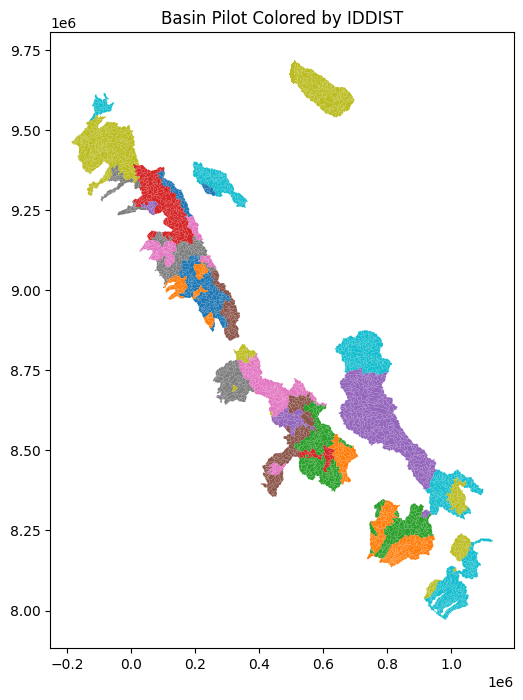

In [4]:
subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
subbasins_gdf.plot(column='IDDIST', legend=False, figsize=(10, 8))
plt.title('Basin Pilot Colored by IDDIST')
plt.show()

In [5]:
#read in infrastructure shapefiles 

#read in pozos 
pozos_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/4_DEMANDAS_DEMANDS/Datos_ANA/Pozos.shp'
#read in bocatomas 
bocatomas_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Bocatomas.shp'
#read in presas
presas_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/4_DEMANDAS_DEMANDS/Datos_ANA/Presas.shp'
#read in canals 
canals_tras_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalTrasvase.shp'
canals_lat_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalLateral.shp'
canals_ad_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalAduccion.shp'
canals_der_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalDerivacion.shp'
#read in reservoirs
embalses_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/embalses_IKI.shp'
#read in aqueducts 
aqueducts_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/4_DEMANDAS_DEMANDS/Datos_ANA/Acueducto.shp'

# Ensure all infrastructure shapefiles have the same CRS as the subbasin shapefile
subbasins_crs = subbasins_gdf.crs  # Get the CRS of the subbasin shapefile

# Reproject infrastructure shapefiles to match the subbasin CRS
bocatomas_gdf = gpd.read_file(bocatomas_shp).to_crs(subbasins_crs)
pozos_gdf = gpd.read_file(pozos_shp).to_crs(subbasins_crs)
presas_gdf = gpd.read_file(presas_shp).to_crs(subbasins_crs)
aqueducts_gdf = gpd.read_file(aqueducts_shp).to_crs(subbasins_crs)
canals_tras_gdf = gpd.read_file(canals_tras_shp).to_crs(subbasins_crs)
canals_lat_gdf = gpd.read_file(canals_lat_shp).to_crs(subbasins_crs)
canals_ad_gdf = gpd.read_file(canals_ad_shp).to_crs(subbasins_crs)
canals_der_gdf = gpd.read_file(canals_der_shp).to_crs(subbasins_crs)
embalses_gdf = gpd.read_file(embalses_shp).to_crs(subbasins_crs)

# List of all infrastructure GeoDataFrames
infrastructure_gdfs = [
    bocatomas_gdf,
    canals_tras_gdf,
    canals_lat_gdf,
    canals_ad_gdf,
    canals_der_gdf,
    embalses_gdf,
    pozos_gdf,
    presas_gdf,     
    aqueducts_gdf
]


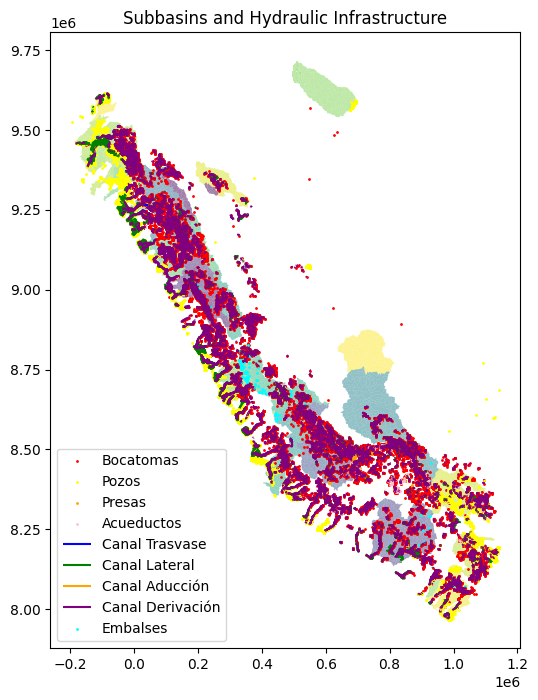

In [6]:
# Plot subbasins and bocatomas on the same plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot subbasins
subbasins_gdf.plot(ax=ax, column='IDDIST', legend=True, cmap='viridis', alpha=0.5)

# Plot bocatomas
bocatomas_gdf.plot(ax=ax, color='red', markersize=1, label='Bocatomas')
pozos_gdf.plot(ax=ax, color='yellow', markersize=1, label='Pozos')
presas_gdf.plot(ax=ax, color='orange', markersize=1, label='Presas')
aqueducts_gdf.plot(ax=ax, color='pink', markersize=1, label='Acueductos')
canals_tras_gdf.plot(ax=ax, color='blue', markersize=1, label='Canal Trasvase')
canals_lat_gdf.plot(ax=ax, color='green', markersize=1, label='Canal Lateral')
canals_ad_gdf.plot(ax=ax, color='orange', markersize=1, label='Canal Aducción')
canals_der_gdf.plot(ax=ax, color='purple', markersize=1, label='Canal Derivación')
embalses_gdf.plot(ax=ax, color='cyan', markersize=1, label='Embalses')


# Add title and legend
plt.title('Subbasins and Hydraulic Infrastructure')
plt.legend()

# Show the plot
plt.show()

In [7]:
# Initialize a dictionary to store counts
basin_feature_counts = {}

# Loop through each subbasin
for basin_id, basin_geometry in zip(subbasins_gdf['COMID'], subbasins_gdf.geometry):
    total_features = 0
    for infra_gdf in infrastructure_gdfs:
        # Count features within the basin
        features_in_basin = infra_gdf[infra_gdf.geometry.within(basin_geometry)].shape[0]
        total_features += features_in_basin
    basin_feature_counts[basin_id] = total_features

# Convert the results to a DataFrame
import pandas as pd
basin_feature_counts_df = pd.DataFrame(list(basin_feature_counts.items()), columns=['COMID', 'Feature_Count'])

# Display the results
print(basin_feature_counts_df)

          COMID  Feature_Count
0     311153600              4
1     310832400              4
2     310825700              1
3     310282400            430
4     308754600             25
...         ...            ...
3650  312029900             12
3651  312046300             30
3652  312066700             43
3653  320251000            282
3654  320254600            408

[3655 rows x 2 columns]


In [8]:
# Merge the feature count DataFrame with the subbasins GeoDataFrame
subbasins_gdf = subbasins_gdf.merge(basin_feature_counts_df, left_on='COMID', right_on='COMID', how='left')
subbasins_gdf

,COMID,GRID_CODE,GRID_COUNT,PROD_UNIT,AREASQKM,Cuenca,grupo_mod,IDDIST,NOMBDIST,geometry,Feature_Count
0,311153600,311152200,588,3,127.529,Cuenca Ilave,11,210112,PLATERIA,"POLYGON ((1044381.708 8220232.343, 1044438.498...",4
1,310832400,310821000,435,3,189.658,Cuenca Ramis,11,210605,PUSI,"POLYGON ((1036078.636 8304636.66, 1036527.471 ...",4
2,310825700,310836800,261,3,67.078,Cuenca Ramis,11,211105,SAN MIGUEL,"POLYGON ((1021175.289 8300811.869, 1021623.963...",1
3,310282400,310247500,809,3,136.619,Cuenca Ica,6,110101,ICA,"POLYGON ((421294.727 8439248.725, 420844.961 8...",430
4,308754600,308772100,544,3,122.208,Cuenca Mantaro,5,190104,HUAYLLAY,"POLYGON ((336025.343 8802045.383, 335569.76 88...",25
...,...,...,...,...,...,...,...,...,...,...,...
3650,312029900,312002100,242,3,49.210,Cuenca Caplina,8,230111,LA YARADA LOS PALOS,"POLYGON ((973180.716 7983299.364, 973203.268 7...",12
3651,312046300,312031700,77,3,15.652,Cuenca Caplina,8,230111,LA YARADA LOS PALOS,"POLYGON ((970564.097 7984750.223, 971447.57 79...",30
3652,312066700,312047300,415,3,84.369,Intercuenca 13155,8,230111,LA YARADA LOS PALOS,"MULTIPOLYGON (((1001919.07 8000617.22, 1001907...",43
3653,320251000,319228200,2130,3,434.256,Intercuenca 13155,8,230111,LA YARADA LOS PALOS,"POLYGON ((983574.448 7974718.391, 983528.11 79...",282


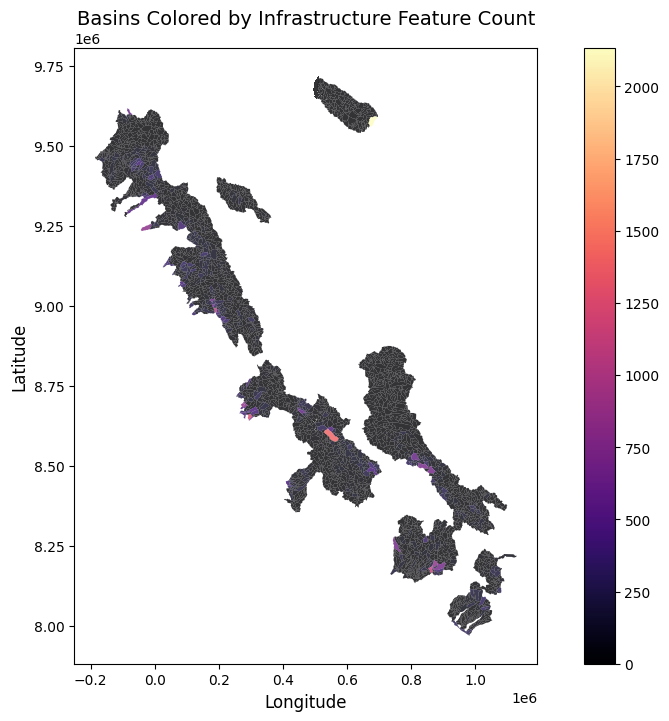

In [9]:
# Plot the basins colored by the feature count
fig, ax = plt.subplots(figsize=(12, 8))
subbasins_gdf.plot(ax=ax, column='Feature_Count', legend=True, cmap='magma', alpha=0.8)

# Add title and labels
plt.title('Basins Colored by Infrastructure Feature Count', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Show the plot
plt.show()

SQLITE INSERT 

In [ ]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID and Feauture_Count
value_column= 'Feature_Count'

In [ ]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [21]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [ ]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()

#TEST FOR JUST ONE COMID TO ENSURE METHOD

C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFr

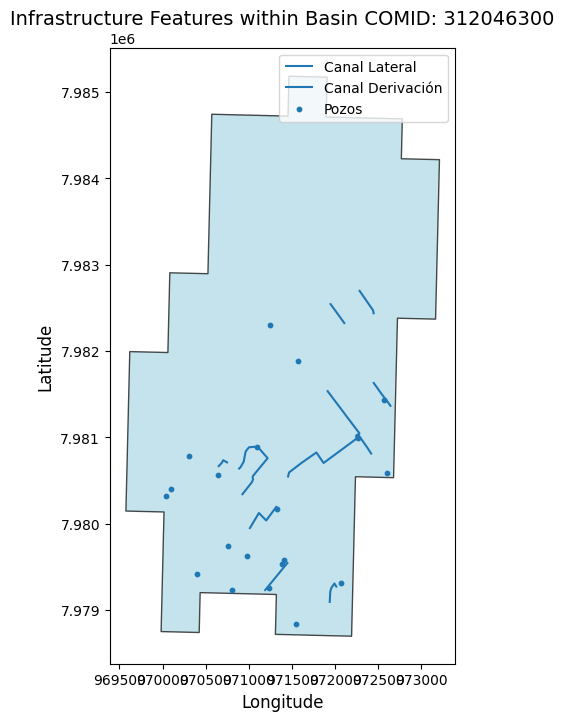

In [ ]:
import matplotlib.pyplot as plt

# Specify the COMID to plot
target_comid = 312046300  # Replace with the desired COMID

# Filter the subbasin for the target COMID
target_basin = subbasins_gdf[subbasins_gdf['COMID'] == target_comid]

# Initialize a plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the target subbasin
target_basin.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.7, label=f'Basin COMID: {target_comid}')

# Plot infrastructure features within the target subbasin
for infra_gdf, label in zip(infrastructure_gdfs, [
    'Bocatomas', 'Canal Trasvase', 'Canal Lateral', 'Canal Aducción', 
    'Canal Derivación', 'Embalses', 'Pozos', 'Presas', 'Acueductos'
]):
    infra_within_basin = infra_gdf[infra_gdf.geometry.within(target_basin.geometry.iloc[0])]
    infra_within_basin.plot(ax=ax, markersize=10, label=label)

# Add title, legend, and labels
plt.title(f'Infrastructure Features within Basin COMID: {target_comid}', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend()

# Show the plot
plt.show()